In [24]:
import pandas as pd
from Modules.text_processor import TextProcessor

# readind the dataset
file_path = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-02-25/article_dat.csv'
df = pd.read_csv(file_path)

# instantiating the text processor
text_processor = TextProcessor(download=False)

In [25]:
df.columns

Index(['pmid', 'doi', 'jabbrv', 'journal', 'year', 'month', 'day', 'title',
       'abstract', 'keywords', 'study_aim', 'study_location',
       'study_year_start', 'study_year_end', 'study_type', 'data_source',
       'race1', 'race1_ss', 'race2', 'race2_ss', 'race3', 'race3_ss', 'race4',
       'race4_ss', 'race5', 'race5_ss', 'race6', 'race6_ss', 'race7',
       'race7_ss', 'race8', 'race8_ss', 'eth1', 'eth1_ss', 'eth2', 'eth2_ss',
       'eth3', 'eth3_ss', 'eth4', 'eth4_ss', 'eth5', 'eth5_ss', 'eth6',
       'eth6_ss', 'eth7', 'eth7_ss', 'eth8', 'eth8_ss', 'access_to_care',
       'treatment_received', 'health_outcome', 'cancer_ovarian',
       'cancer_uterine', 'cancer_cervical', 'cancer_vulvar', 'other_gyn_onc',
       'endo', 'fibroids', 'other_gyn_surg', 'fert', 'matmorbmort',
       'other_preg', 'phys_div', 'other', 'covid'],
      dtype='str')

In [26]:
text_1 = df['title'][0]
" ".join(text_processor.preprocess(text=text_1))

'desired sterilization procedure time cesarean delivery according insurance status'

In [27]:
abstracts = df['abstract'].apply(
    lambda x: text_processor.preprocess(x)
)
df['processed_abstracts'] = abstracts

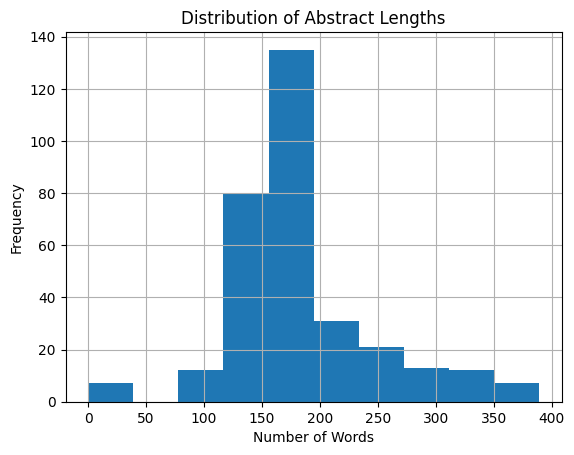

In [28]:
import matplotlib.pyplot as plt
plt.hist([len(abstract) for abstract in abstracts])
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Abstract Lengths")
plt.grid(True)
plt.show()

Il faut donc qu'on enlève les abstracts de moins de 50 mots. car il n'y en a pas de moins de 50.

In [29]:
# removing abstracts with less than 50 words because we have some abstracts with very few words like 0 and we want to focus on more substantial abstracts for our analysis
# df = df[df['processed_abstracts'].str.split().apply(len) > 50]

## Frequences des mots dans le corpus

In [30]:
df['processed_abstracts'].head()

0    [evaluate, whether, women, medicaid, less, lik...
1    [compare, postoperative, outcomes, primary, pa...
2    [germline, mutations, occur, approximately, pa...
3    [evaluate, patients, advanced, ovarian, cancer...
4    [although, black, patients, endometrial, cance...
Name: processed_abstracts, dtype: object

In [31]:
all_absracts_cleaned = df['processed_abstracts'].apply(lambda x: " ".join(x))
all_absracts_cleaned = " ".join(all_absracts_cleaned)
dict_of_words_occurences = text_processor.count_word_frequencies(text=all_absracts_cleaned, top_n=10000, preprocess=False)
len(dict_of_words_occurences)

4664

In [32]:
dict_of_words_occurences

{'women': 1538,
 'black': 828,
 'white': 700,
 'patients': 679,
 'cancer': 646,
 'hispanic': 605,
 'ci': 589,
 'race': 485,
 'among': 469,
 'risk': 458,
 'non': 448,
 'compared': 443,
 'racial': 375,
 'care': 370,
 'lt': 370,
 'adjusted': 334,
 'study': 326,
 'survival': 326,
 'treatment': 321,
 'maternal': 307,
 'associated': 301,
 'pregnancy': 300,
 'vs': 290,
 'ratio': 288,
 'confidence': 286,
 'odds': 285,
 'disparities': 278,
 'interval': 262,
 'higher': 259,
 'age': 255,
 'rates': 245,
 'likely': 243,
 'differences': 233,
 'ethnicity': 223,
 'data': 212,
 'birth': 210,
 'mortality': 209,
 'analysis': 208,
 'endometrial': 205,
 'stage': 204,
 'using': 195,
 'outcomes': 193,
 'morbidity': 193,
 'used': 192,
 'severe': 190,
 'factors': 189,
 'delivery': 188,
 'ethnic': 181,
 'years': 179,
 'american': 174,
 'ovarian': 173,
 'regression': 170,
 'less': 169,
 'overall': 167,
 'increased': 164,
 'health': 162,
 'significantly': 159,
 'identified': 158,
 'african': 157,
 'disease': 156,

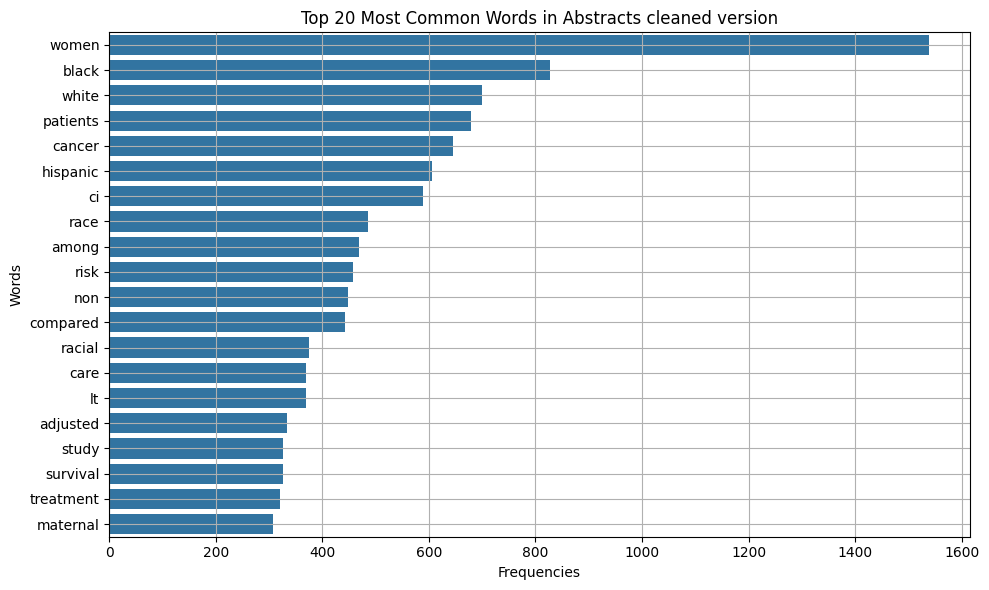

In [33]:
from Modules.graphic_drawer import GraphicDrawer
graphic_drawer = GraphicDrawer()
graphic_drawer.draw_bar_plot(dict_of_words_occurences, top_n=20, title="Top 20 Most Common Words in Abstracts cleaned version", ylabel="Words", xlabel="Frequencies")

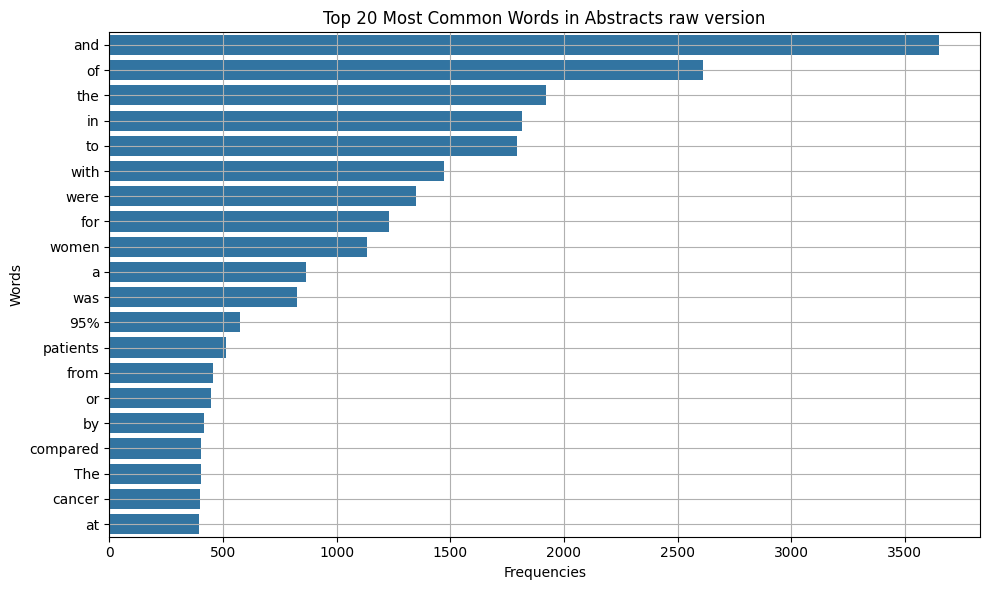

In [34]:
all_absracts_raw = " ".join(df['abstract'].apply(lambda x: str(x)))
dict_of_words_occurences_raw_version = text_processor.count_word_frequencies(all_absracts_raw, top_n=1000000000, preprocess=False)
graphic_drawer.draw_bar_plot(dict_of_words_occurences_raw_version, top_n=20, title="Top 20 Most Common Words in Abstracts raw version", ylabel="Words", xlabel="Frequencies")

In [35]:
len(dict_of_words_occurences_raw_version)

13417

On voit qu'avant le traitement du texte, les mots inutile telsque `and, of, the, to, with, were, for, a, the` etc. sont présent dans le corpus avant traitement. Alors qu'après traitement ceux-ci disparaissent (`13417 vs 4664`).

**Faire un word cloud pour cela**

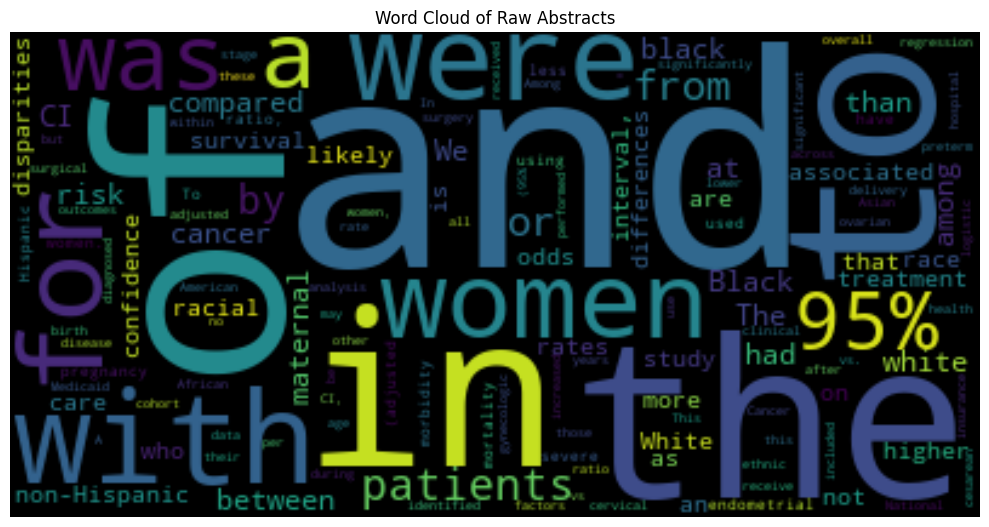

In [36]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences_raw_version, title="Word Cloud of Raw Abstracts")

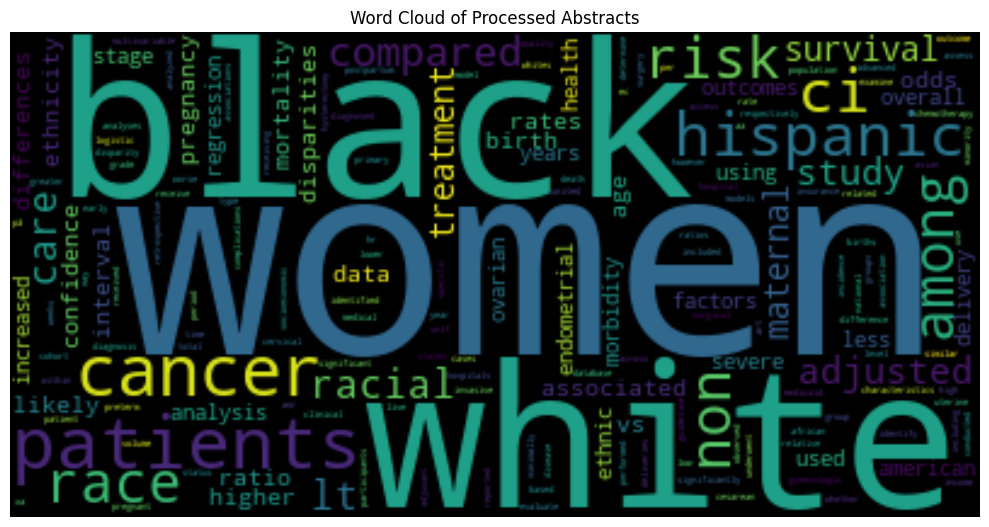

In [37]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences, title="Word Cloud of Processed Abstracts")

On voit qu'avant le traitement du texte, les mots inutile telsque `and, of, the, to, with, were, for, a, the` etc. sont présent dans le corpus avant traitement. Alors qu'après traitement ceux-ci disparaissent (`13417 vs 4664`).

Avec `tf-idf`, on aura des vecteurs de `4664` dimensions par abstract, ce qui est enorme et problématique. En effet pour clusteriser/classifier nos articles sur la base des abstracts, il faut les vectoriser et calculer des métriques de similarités (distance, cosinus similarité etc...) entre eux. Or les distances , normes deviennent moins informatives dans un espace de grande dimension. Pour cela, nous utiliserons le `SciBert` qui permet de palier à ce problème et même fait plus : il tient compte de l'aspect sémantique des abstract au lieu de se baser sur le nombre d'occurences qui certes encode l'aspect semantique comme vue avec la `fréquence des mots` vue en amont (**On arrive à voir quand même de quoi le corpus parle en générale**) mais moins précis.

Par conséquent pour utiliser `SciBert`, il faut respecter au mieux la structure sémantique. Donc supprimer `les stopwords`, `tokenizer`, supprimer certains `regex` comme les `chiffres`, la `ponctuation` peuvent fortemen casser le sens des abstracts. Les autres traitements restent valables (du coup on va redinir notre classe) pour tenir compte d'un `preprocessing` adapté à la vectorisation `SciBert`.

# Vectorisation des abstracts avec SciBERT

## Formalisme et cas d’usage du transformer

---

## 1. Entrée du modèle (tokenization)

Soit un texte :

"deep learning for image classification"

Après tokenization avec SciBERT :

inputs["input_ids"] =
[101, 2784, 4083, 2005, 3746, 5579, 102]

inputs["attention_mask"] =
[1, 1, 1, 1, 1, 1, 1]

### Interprétation :

- 101 = token [CLS] (début de phrase)
- 102 = token [SEP] (fin de phrase)
- les autres = tokens du texte

---

## 1.1 Qu’est-ce que [PAD] ?

Le token [PAD] signifie padding (remplissage).

Il est utilisé lorsque plusieurs textes sont traités ensemble (batch), car ils n’ont pas la même longueur.

### Exemple :

"deep learning"  
"climate change impacts marine ecosystems"

Devient :

["deep", "learning", [PAD], [PAD], [PAD]]  
["climate", "change", "impacts", "marine", "ecosystems"]

### Rôle de [PAD] :

- rendre toutes les séquences de même longueur
- permettre le traitement en batch
- ne pas ajouter d’information sémantique

---

## 1.2 Attention mask

Pour éviter que [PAD] influence le modèle, on utilise un attention mask :

attention_mask:
[1, 1, 0, 0, 0]

- 1 = vrai token (important)
- 0 = padding (ignoré)

---

## 2. Sortie du modèle BERT

On applique :

outputs = model(**inputs)

Le modèle retourne :

outputs.last_hidden_state  
shape = (batch_size, sequence_length, hidden_size)

### Exemple concret :

shape = (1, 7, 768)

### Interprétation :

Chaque token devient un vecteur de dimension 768 :

token 1 ([CLS])      → vector (768)  
token 2 ("deep")     → vector (768)  
token 3 ("learning") → vector (768)  
...  
token 7 ([SEP])      → vector (768)

---

## 3. Pourquoi on ne peut pas utiliser directement BERT

On veut UN vecteur par phrase :

$$
(1, 768)
$$

Mais BERT donne :

$$
(1, 7, 768)
$$

Donc il faut une opération de réduction : pooling.

---

## 4. Mean pooling (idée mathématique)

Soit :

$$
H = [h_1, h_2, ..., h_n]
$$

où chaque $h_i \in \mathbb{R}^{768}$

Mean pooling :

$$
h_{\text{sentence}} = \frac{1}{n} \sum_{i=1}^{n} h_i
$$

---

## 4.1 Mean pooling avec attention mask

Sans attention mask, les tokens [PAD] influencent la moyenne.

Avec mask :

$$
h = \frac{\sum_{i=1}^{n} m_i h_i}{\sum_{i=1}^{n} m_i}
$$

où :

- $m_i = 1$ si token valide  
- $m_i = 0$ si [PAD]

---

## 5. Code correspondant

```python
token_embeddings = outputs.last_hidden_state

mask = attention_mask.unsqueeze(-1)
mask = mask.expand(token_embeddings.size())

masked_embeddings = token_embeddings * mask

summed = masked_embeddings.sum(dim=1)
counts = mask.sum(dim=1)

sentence_embedding = summed / counts

In [38]:
text_processor_with_scibert = TextProcessor(use_scibert=True, download=False)
abstracts_scibert = df['abstract'].apply(
    lambda x: text_processor_with_scibert.preprocess(x)
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 19898.12it/s]
BertModel LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
abstracts_scibert

0      To evaluate whether women with Medicaid are le...
1      To compare postoperative outcomes by primary p...
2      Germline mutations occur in approximately 25% ...
3      To evaluate patients with advanced ovarian can...
4      Although black patients with endometrial cance...
                             ...                        
313    To evaluate trends by race in Agency for Healt...
314    To develop and internally validate risk predic...
315    To assess the association between allostatic l...
316    To investigate factors associated with differe...
317    To examine postoperative 30-day morbidity and ...
Name: abstract, Length: 318, dtype: str

In [41]:
df['abstracts_scibert'] = abstracts_scibert
# df['abstracts_scibert'] = df['abstracts_scibert'].apply(lambda x: " ".join(x))
all_absracts_scibert = " ".join(df['abstracts_scibert'].apply(lambda x: str(x)))
dict_of_words_occurences_scibert_version = text_processor_with_scibert.count_word_frequencies(all_absracts_scibert, top_n=1000000000, preprocess=False)
len(dict_of_words_occurences_scibert_version)

13414

On passe de `4664` à `13414` le nombre de mots uniques du corpus a donc beaucoup augmenté en se rapprochant du nombre de mots du texte non traité qui est de `13417`.

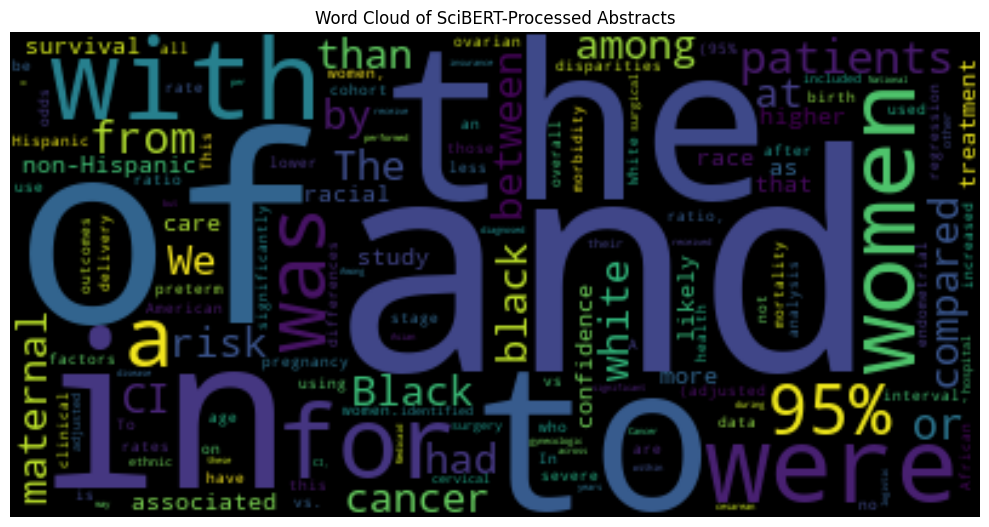

In [ ]:
graphic_drawer.draw_wordcloud_from_freq(dict_of_words_occurences_scibert_version, title="Word Cloud of SciBERT-Processed Abstracts")

Là on peut voir la présense des chiffres notament `95%` pour des IC ou des tests statistiques et des `stopwords` `(to, or, etc.)`, ce qui permet de garder le contexte des données. Les trois mots manquant peuvent venir du fait qu'on ai supprimé les adresses `eamils`, les `urls`, les `tags html` et les espaces supplémentaires. Maintenant nous pouvons passer à la vectorisation.

## VECTORISATION DU TEXTE

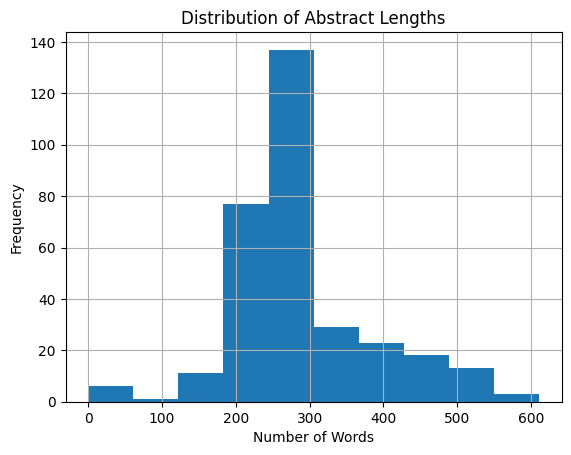

In [49]:
import matplotlib.pyplot as plt
plt.hist([len(abstract) for abstract in abstracts_scibert.apply(lambda x: str(x).split())])
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.title("Distribution of Abstract Lengths")
plt.grid(True)
plt.show()

In [56]:
# suppression des abstracts avec moins de 50 mots après le traitement avec SciBERT pour se concentrer sur les abstracts plus substantiels
df = df[df['abstracts_scibert'].str.split().apply(len) > 0]

La version gratuite de `SciBert` nous donne accès à des tokens de longueur `512` pour chaque élément de notre corpus. Ce qui correspond à environ `250 mots`. Or la distribution ici montre qu'on des abstract allant jusqu'à `600` mots avec le mode qui est autour de `300`. Il faut donc faire du `chunking` pour utiliser plusieurs fois les `512` tokens sur un élement du corpus c'est à dire un abstract si son nombre de mots excède les 250 (nécessite plus de 512 tokens).